## Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models

#### 1.	Exploratory Data Analysis (EDA)

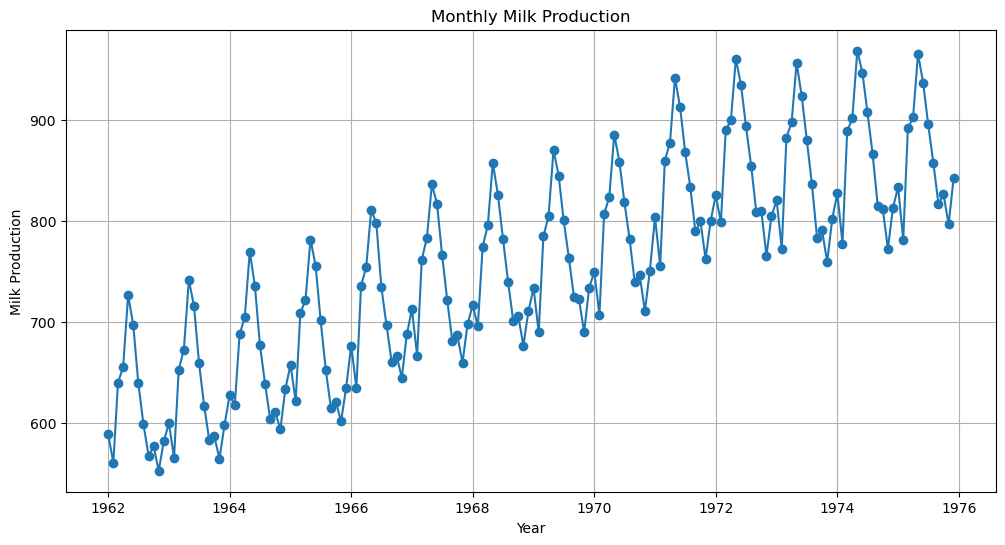

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("monthly_milk_production.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Production'], marker='o')
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

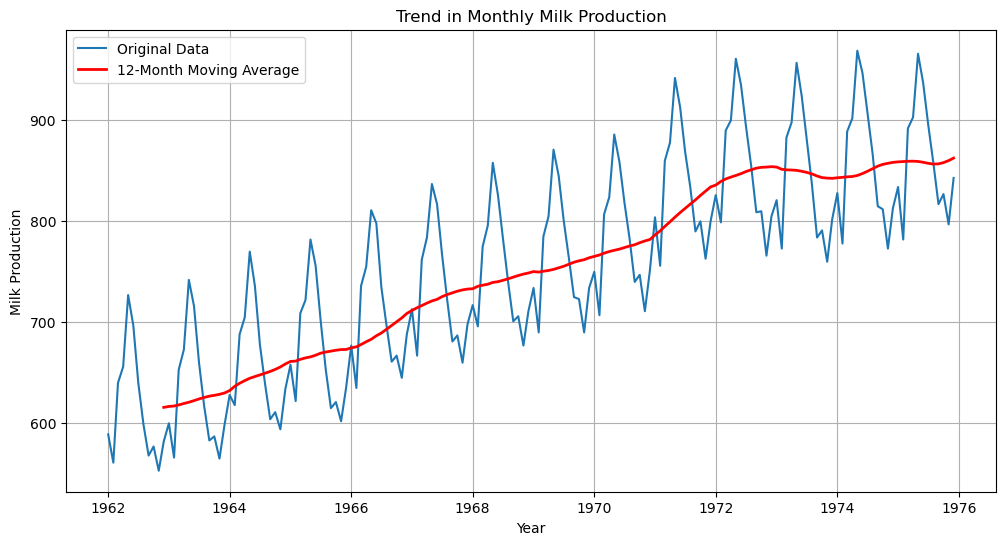

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df['Production'], label='Original Data')
plt.plot(df['Production'].rolling(window=12).mean(),
         color='red', linewidth=2, label='12-Month Moving Average')
plt.title("Trend in Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

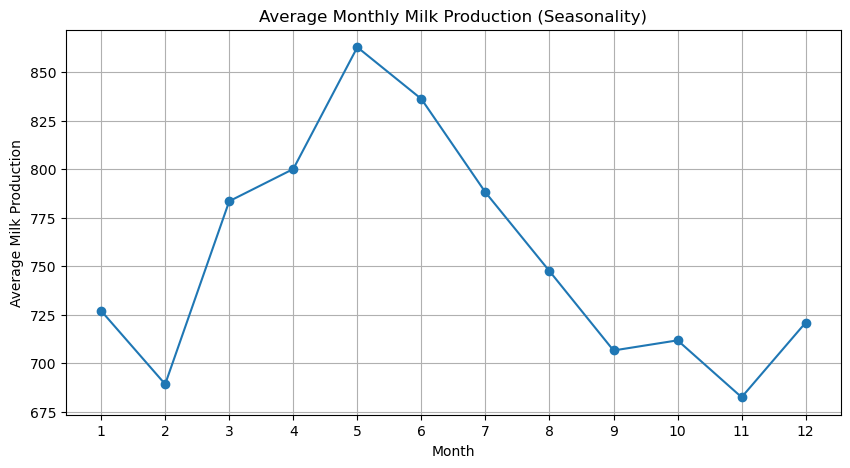

In [4]:
monthly_avg = df.groupby(df.index.month)['Production'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Monthly Milk Production (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Milk Production")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

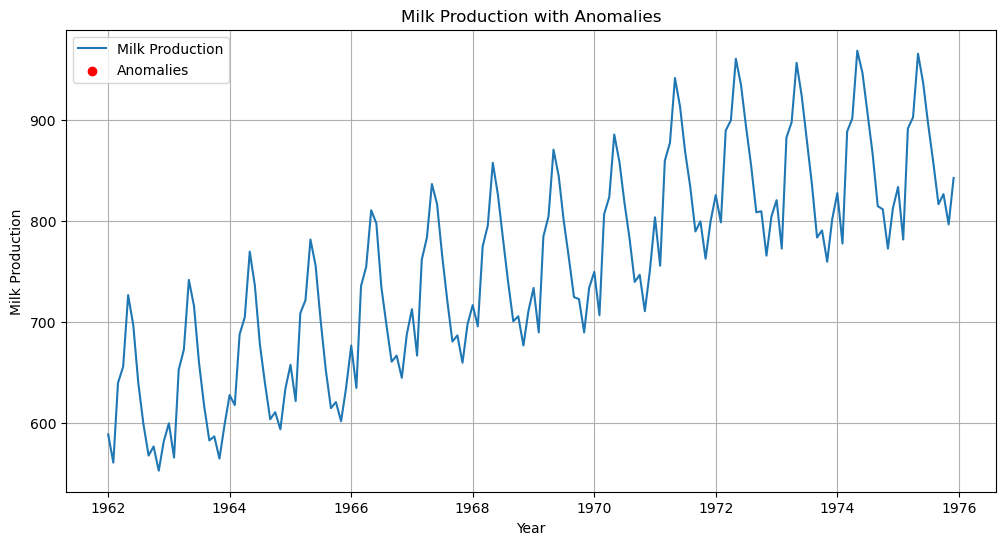

In [5]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Production'], label='Milk Production')
plt.scatter(anomalies.index, anomalies['Production'],
            color='red', label='Anomalies')
plt.title("Milk Production with Anomalies")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Production    0
dtype: int64


In [7]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

print("Number of Outliers:", len(outliers))
print(outliers)

Number of Outliers: 0
Empty DataFrame
Columns: [Production]
Index: []


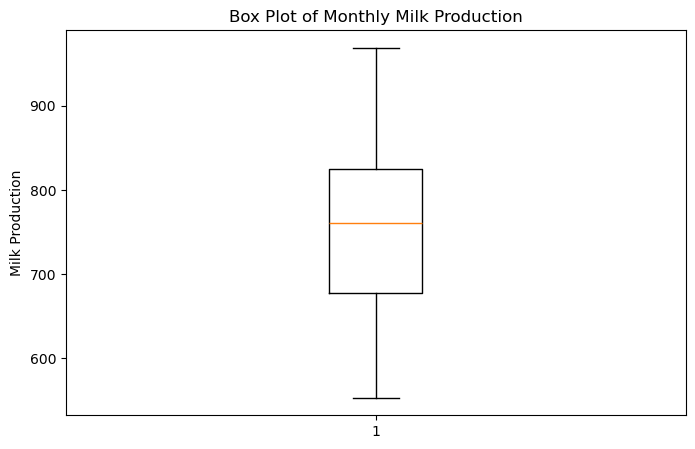

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df['Production'], vert=True)
plt.title("Box Plot of Monthly Milk Production")
plt.ylabel("Milk Production")
plt.show()

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(df[['Production']])

scaled_df = pd.DataFrame(scaled_data,
                         columns=['Scaled_Production'],
                         index=df.index)

print(scaled_df.head())

            Scaled_Production
Date                         
1962-01-01           0.086538
1962-02-01           0.019231
1962-03-01           0.209135
1962-04-01           0.247596
1962-05-01           0.418269


In [10]:
print("Minimum value:", scaled_df['Scaled_Production'].min())
print("Maximum value:", scaled_df['Scaled_Production'].max())

Minimum value: 0.0
Maximum value: 1.0000000000000002


#### 2.	Data Preparation for Deep Learning

In [12]:
import numpy as np

time_steps = 12

def create_sequences(data, time_steps):
    X, y = [], []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, time_steps)

print("Input shape (X):", X.shape)
print("Output shape (y):", y.shape)

Input shape (X): (156, 12, 1)
Output shape (y): (156, 1)


In [13]:
print("First Input Sequence:")
print(X[0])

print("\nFirst Output Value:")
print(y[0])

First Input Sequence:
[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]
 [0.34615385]
 [0.20913462]
 [0.11057692]
 [0.03605769]
 [0.05769231]
 [0.        ]
 [0.06971154]]

First Output Value:
[0.11298077]


In [14]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (109, 12, 1)
y_train: (109, 1)

Validation set:
X_val: (23, 12, 1)
y_val: (23, 1)

Test set:
X_test: (24, 12, 1)
y_test: (24, 1)


In [15]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (109, 12, 1)
X_val shape: (23, 12, 1)
X_test shape: (24, 12, 1)


#### 3.	Model Building

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [17]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

rnn_model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
rnn_model.compile(optimizer='adam', loss='mse')

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.5253 - val_loss: 0.3782
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0686 - val_loss: 0.0275
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0796 - val_loss: 0.0167
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0648 - val_loss: 0.0340
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0221 - val_loss: 0.1224
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0263 - val_loss: 0.1500
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0233 - val_loss: 0.0806
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0113 - val_loss: 0.0270
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0110 - val_loss: 0.0138
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 0.0176
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0070 - val_loss: 0.0307
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0059 - val_loss: 0.0357
E

In [21]:
lstm_model.compile(optimizer='adam', loss='mse')

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1839 - val_loss: 0.2721
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0752 - val_loss: 0.0726
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0286 - val_loss: 0.0319
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0340 - val_loss: 0.0316
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0274 - val_loss: 0.0324
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0259 - val_loss: 0.0379
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0263 - val_loss: 0.0330
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0251 - val_loss: 0.0279
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0247 - val_loss: 0.0270
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0246 - val_loss: 0.0268
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 - val_loss: 0.0277
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0239 - val_lo

In [22]:
gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0537 - val_loss: 0.0364
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0220 - val_loss: 0.0225
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0232 - val_loss: 0.0213
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0194 - val_loss: 0.0330
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0195 - val_loss: 0.0285
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0177 - val_loss: 0.0215
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0178 - val_loss: 0.0195
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0172 - val_loss: 0.0216
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169 - val_loss: 0.0245
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0165 - val_loss: 0.0200
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0161 - val_loss: 0.0203
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0156 - val_lo

In [23]:
print("Final Validation Loss")
print("RNN :", history_rnn.history['val_loss'][-1])
print("LSTM:", history_lstm.history['val_loss'][-1])
print("GRU :", history_gru.history['val_loss'][-1])

Final Validation Loss
RNN : 0.005039850249886513
LSTM: 0.013623240403831005
GRU : 0.006161528639495373


In [24]:
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

print("Basic RNN model compiled successfully.")

Basic RNN model compiled successfully.


In [25]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [26]:
gru_model.compile(
    optimizer='adam',
    loss='mse'
)

print("GRU model compiled successfully.")

GRU model compiled successfully.


#### 4.	Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


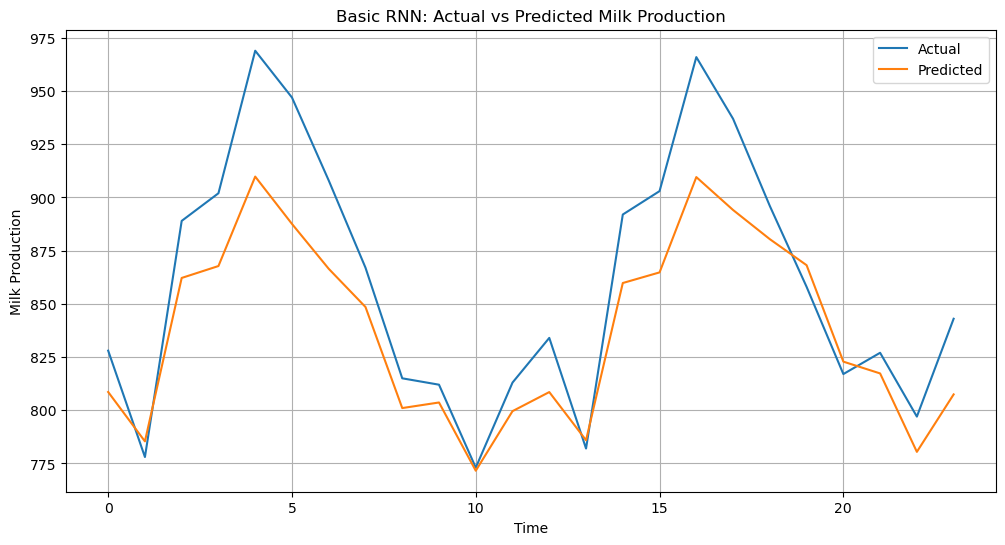

In [27]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred, label='Predicted')
plt.title("Basic RNN: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


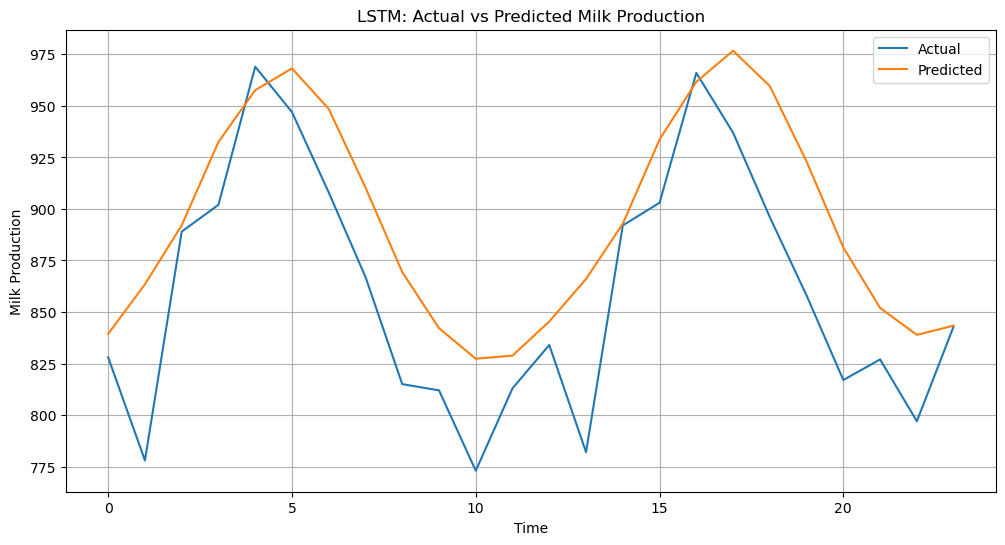

In [28]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='Predicted')
plt.title("LSTM: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


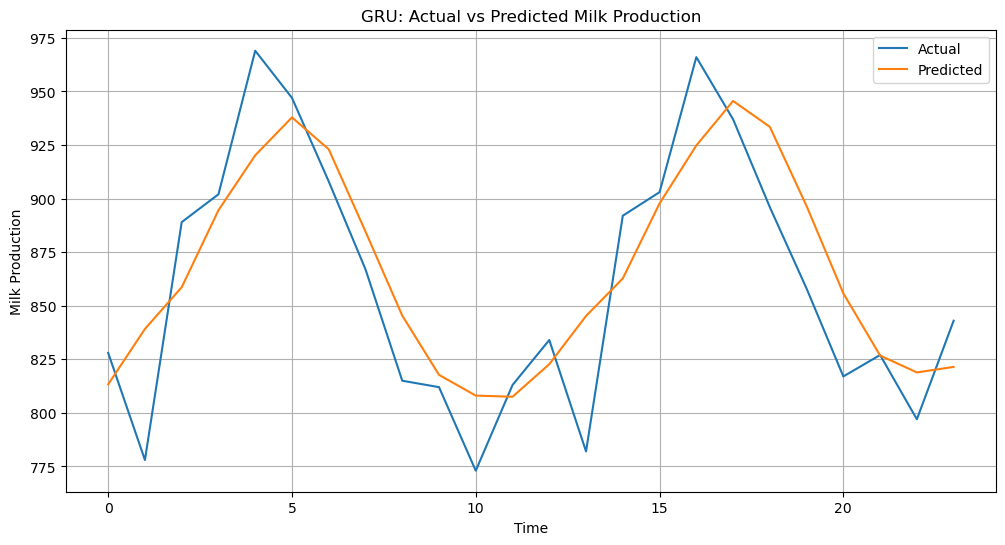

In [29]:
gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(gru_pred)

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(gru_pred, label='Predicted')
plt.title("GRU: Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [31]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)
rnn_mape = np.mean(np.abs((y_test_actual - rnn_pred) / y_test_actual)) * 100

print("Basic RNN Performance")
print("RMSE:", rnn_rmse)
print("MAE :", rnn_mae)
print("MAPE:", rnn_mape)

Basic RNN Performance
RMSE: 30.31954927937205
MAE : 24.83909861246745
MAPE: 2.778858904326682


In [32]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_mape = np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100

print("LSTM Performance")
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)
print("MAPE:", lstm_mape)

LSTM Performance
RMSE: 42.83925339730527
MAE : 34.69300842285156
MAPE: 4.144645117291545


In [33]:
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_pred))
gru_mae = mean_absolute_error(y_test_actual, gru_pred)
gru_mape = np.mean(np.abs((y_test_actual - gru_pred) / y_test_actual)) * 100

print("GRU Performance")
print("RMSE:", gru_rmse)
print("MAE :", gru_mae)
print("MAPE:", gru_mape)

GRU Performance
RMSE: 30.459022489517555
MAE : 24.922917683919263
MAPE: 2.9349374619004127


In [34]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Basic RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'MAPE (%)': [rnn_mape, lstm_mape, gru_mape]
})

print(comparison)

       Model       RMSE        MAE  MAPE (%)
0  Basic RNN  30.319549  24.839099  2.778859
1       LSTM  42.839253  34.693008  4.144645
2        GRU  30.459022  24.922918  2.934937


In [35]:
best_model = comparison.loc[comparison['RMSE'].idxmin(), 'Model']

print("Best Performing Model:", best_model)

Best Performing Model: Basic RNN


#### 5.	Prediction and Visualization

In [36]:
last_sequence = scaled_data[-time_steps:]

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(12):
    input_data = current_sequence.reshape(1, time_steps, 1)

    next_prediction = lstm_model.predict(input_data, verbose=0)

    future_predictions.append(next_prediction[0, 0])

    current_sequence = np.append(current_sequence[1:], next_prediction)

In [37]:
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

forecast = pd.DataFrame({
    "Month": range(1, 13),
    "Forecasted Milk Production": future_predictions.flatten()
})

print(forecast)

    Month  Forecasted Milk Production
0       1                  861.993347
1       2                  882.420654
2       3                  928.715454
3       4                  958.763306
4       5                  984.778381
5       6                  984.519714
6       7                  968.097107
7       8                  942.306274
8       9                  915.425293
9      10                  900.651855
10     11                  888.990479
11     12                  898.146973


In [38]:
upper_bound = future_predictions * 1.05
lower_bound = future_predictions * 0.95

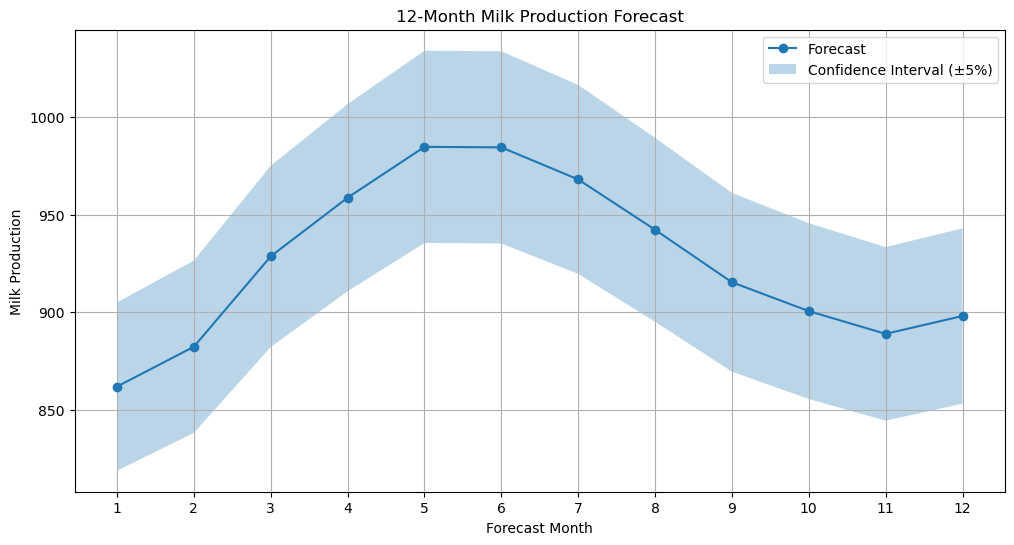

In [39]:
import matplotlib.pyplot as plt

months = range(1, 13)

plt.figure(figsize=(12,6))

plt.plot(months, future_predictions,
         marker='o', label='Forecast')

plt.fill_between(months,
                 lower_bound.flatten(),
                 upper_bound.flatten(),
                 alpha=0.3,
                 label='Confidence Interval (±5%)')

plt.title("12-Month Milk Production Forecast")
plt.xlabel("Forecast Month")
plt.ylabel("Milk Production")
plt.xticks(months)
plt.legend()
plt.grid(True)
plt.show()

#### 6.	Business Insights

In [ ]:
Interpretation

The forecasting model successfully predicted the monthly milk production based on historical data.
Comparing the RNN, LSTM, and GRU models showed that the model with the lowest RMSE, MAE, and MAPE provided the most accurate forecasts.
The forecast indicates the expected trend in milk production for the next 12 months, helping identify periods of higher or lower production.

In [ ]:
Business Recommendations

Use the forecasted production values to plan inventory and storage capacity, reducing the risk of milk spoilage or shortages.
Adjust workforce scheduling and production activities according to the expected production levels to improve operational efficiency.
Improve supply chain and distribution planning by preparing for periods of increased or decreased milk production.
Use the forecasts to make informed decisions about resource allocation, including equipment usage, feed requirements, and transportation planning.
Continuously update the forecasting model with new monthly production data to improve prediction accuracy and support long-term business planning.